#  Imports

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


# Load Data and Basic Cleaning

In [74]:
# Load the CSV
df = pd.read_csv(r"D:\BI_NI_CI\ModelAllData2.csv")

# Basic cleaning
df['Miladi'] = pd.to_datetime(df['Miladi'], errors='coerce')
df = df.dropna(subset=['Miladi', 'GoodsID', 'MainQty'])

# Ensure numeric quantity
df['MainQty'] = pd.to_numeric(df['MainQty'], errors='coerce').fillna(0)

C:\Users\M Zafar\AppData\Local\Temp\ipykernel_11700\2385254726.py:2: DtypeWarning: Columns (11,15,16,17,18,19,23,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\BI_NI_CI\ModelAllData2.csv")


In [75]:
df

,GoodsID,datasrcid,GoodsID.1,Code,Name,jdate,Miladi,Quarter,IsHoliday,MainQty,...,Group6Material,Group7Color,Group8Size,Group9Property,Group10Presenter,Group11Brand,Group12,Group13,Group14,Group15
0,53212,4,53212,28306,پتانسیومتر دریچه گاز ساژم پیکان دناکو (دناکو D...,1403/09/29,2024-12-19,3,0,1.0,...,هيچکدام,هيچکدام,هيچکدام,ساژم,NaN,دناکو DENACO,NaN,پتانسیومتر,NaN,پتانسیومتر دریچه گاز ساژم پیکان دناکو\t
1,53212,4,53212,28306,پتانسیومتر دریچه گاز ساژم پیکان دناکو (دناکو D...,1403/09/20,2024-12-10,3,0,1.0,...,هيچکدام,هيچکدام,هيچکدام,ساژم,NaN,دناکو DENACO,NaN,پتانسیومتر,NaN,پتانسیومتر دریچه گاز ساژم پیکان دناکو\t
2,53212,4,53212,28306,پتانسیومتر دریچه گاز ساژم پیکان دناکو (دناکو D...,1403/09/01,2024-11-21,3,0,1.0,...,هيچکدام,هيچکدام,هيچکدام,ساژم,NaN,دناکو DENACO,NaN,پتانسیومتر,NaN,پتانسیومتر دریچه گاز ساژم پیکان دناکو\t
3,53212,4,53212,28306,پتانسیومتر دریچه گاز ساژم پیکان دناکو (دناکو D...,1403/08/06,2024-10-27,3,0,0.0,...,هيچکدام,هيچکدام,هيچکدام,ساژم,NaN,دناکو DENACO,NaN,پتانسیومتر,NaN,پتانسیومتر دریچه گاز ساژم پیکان دناکو\t
4,53212,4,53212,28306,پتانسیومتر دریچه گاز ساژم پیکان دناکو (دناکو D...,1403/06/28,2024-09-18,2,0,1.0,...,هيچکدام,هيچکدام,هيچکدام,ساژم,NaN,دناکو DENACO,NaN,پتانسیومتر,NaN,پتانسیومتر دریچه گاز ساژم پیکان دناکو\t
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1380737,80426,4,80426,36494,صافی بنزین سر کج پراید LOCO MOBIL (لوکو مبیل L...,1404/08/24,2025-11-15,3,0,1.0,...,NaN,NaN,NaN,NaN,NaN,لوکو مبیل LOCO MOBIL,NaN,NaN,NaN,NaN
1380738,80429,4,80429,36497,براکت سپر جلو چپ EFP سمند,1404/08/25,2025-11-16,3,0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1380739,80436,4,80436,36501,گلگیر عقب چپ ساینا,1404/08/24,2025-11-15,3,0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1380740,80472,4,80472,36531,صندلی کامل طرح ناتیس پژو 206 (طرح ناتیس),1404/08/25,2025-11-16,3,0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Feature Engineering

## Basics

In [76]:

# Feature engineering (daily level)
df['year'] = df['Miladi'].dt.year
df['month'] = df['Miladi'].dt.month
df['quarter'] = df['Miladi'].dt.quarter

# convert IsHoliday to numeric
df['IsHoliday'] = df['IsHoliday'].astype(int)
df.sort_values(['GoodsID', 'year', 'month'])

,GoodsID,datasrcid,GoodsID.1,Code,Name,jdate,Miladi,Quarter,IsHoliday,MainQty,...,Group9Property,Group10Presenter,Group11Brand,Group12,Group13,Group14,Group15,year,month,quarter
1038661,50608,4,50608,10968,اسپری پنچری GOLD (گلد GOLD),1403/09/10,2024-11-30,3,0,1.0,...,NaN,NaN,گلد GOLD,NaN,اسپري,آپشن عمومی,اسپری پنچری GOLD,2024,11,4
1038662,50608,4,50608,10968,اسپری پنچری GOLD (گلد GOLD),1403/09/06,2024-11-26,3,0,1.0,...,NaN,NaN,گلد GOLD,NaN,اسپري,آپشن عمومی,اسپری پنچری GOLD,2024,11,4
1038663,50608,4,50608,10968,اسپری پنچری GOLD (گلد GOLD),1403/09/03,2024-11-23,3,0,1.0,...,NaN,NaN,گلد GOLD,NaN,اسپري,آپشن عمومی,اسپری پنچری GOLD,2024,11,4
1038650,50608,4,50608,10968,اسپری پنچری GOLD (گلد GOLD),1403/10/11,2024-12-31,4,0,1.0,...,NaN,NaN,گلد GOLD,NaN,اسپري,آپشن عمومی,اسپری پنچری GOLD,2024,12,4
1038651,50608,4,50608,10968,اسپری پنچری GOLD (گلد GOLD),1403/10/05,2024-12-25,4,0,1.0,...,NaN,NaN,گلد GOLD,NaN,اسپري,آپشن عمومی,اسپری پنچری GOLD,2024,12,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1380737,80426,4,80426,36494,صافی بنزین سر کج پراید LOCO MOBIL (لوکو مبیل L...,1404/08/24,2025-11-15,3,0,1.0,...,NaN,NaN,لوکو مبیل LOCO MOBIL,NaN,NaN,NaN,NaN,2025,11,4
1380738,80429,4,80429,36497,براکت سپر جلو چپ EFP سمند,1404/08/25,2025-11-16,3,0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,11,4
1380739,80436,4,80436,36501,گلگیر عقب چپ ساینا,1404/08/24,2025-11-15,3,0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,11,4
1380740,80472,4,80472,36531,صندلی کامل طرح ناتیس پژو 206 (طرح ناتیس),1404/08/25,2025-11-16,3,0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,11,4


## Aggregates

In [77]:
from itertools import product

def fill_missing_months(df, year_col='year', month_col='month', group_col='GoodsID'):
    min_year = df[year_col].min()
    max_year = df[year_col].max()
    
    # پیدا کردن آخرین ماه در آخرین سال
    max_month_in_max_year = df[df[year_col] == max_year][month_col].max()
    
    # پیدا کردن اولین ماه در اولین سال
    min_month_in_min_year = df[df[year_col] == min_year][month_col].min()
    
    all_products = df[group_col].unique()
    
    # ساخت ترکیبات سال-ماه به صورت دستی (فقط محدوده معتبر)
    valid_year_months = []
    for year in range(int(min_year), int(max_year) + 1):
        if year == min_year and year == max_year:
            # اگر فقط یک سال داریم
            months = range(int(min_month_in_min_year), int(max_month_in_max_year) + 1)
        elif year == min_year:
            # سال اول: از اولین ماه تا 12
            months = range(int(min_month_in_min_year), 13)
        elif year == max_year:
            # سال آخر: از 1 تا آخرین ماه
            months = range(1, int(max_month_in_max_year) + 1)
        else:
            # سال‌های میانی: همه ماه‌ها
            months = range(1, 13)
        
        for month in months:
            valid_year_months.append((year, month))
    
    # ساخت تمام ترکیبات
    all_combinations = pd.DataFrame(
        [(prod, ym[0], ym[1]) for prod in all_products for ym in valid_year_months],
        columns=[group_col, year_col, month_col]
    )
    
    result = pd.merge(
        all_combinations, 
        df, 
        on=[group_col, year_col, month_col], 
        how='left'
    )
    
    result['quarter'] = ((result[month_col] - 1) // 3) + 1
    result['year_month_order'] = result[year_col] * 12 + result[month_col]
    result = result.sort_values([group_col, year_col, month_col]).reset_index(drop=True)
    
    return result

# استفاده
monthly = (
    df.groupby(['GoodsID', 'year', 'month', 'quarter'], as_index=False)
    .agg({'MainQty': 'sum', 'Price': 'mean'})
)
monthly = fill_missing_months(monthly)

print(f"تعداد ردیف بعد از پر کردن: {len(monthly)}")
print(f"تعداد ماه‌های گم شده پر شده: {monthly['MainQty'].isna().sum()}")
print(f"محدوده تاریخ: {monthly['year'].min()}/{monthly['month'].min()} تا {monthly['year'].max()}/{monthly['month'].max()}")

monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
monthly

تعداد ردیف بعد از پر کردن: 988764
تعداد ماه‌های گم شده پر شده: 659994
محدوده تاریخ: 2022/1 تا 2025/12


,GoodsID,year,month,quarter,MainQty,Price,year_month_order,date
0,50608,2022,6,2,NaN,NaN,24270,2022-06-01
1,50608,2022,7,3,NaN,NaN,24271,2022-07-01
2,50608,2022,8,3,NaN,NaN,24272,2022-08-01
3,50608,2022,9,3,NaN,NaN,24273,2022-09-01
4,50608,2022,10,4,NaN,NaN,24274,2022-10-01
...,...,...,...,...,...,...,...,...
988759,80476,2025,7,3,NaN,NaN,24307,2025-07-01
988760,80476,2025,8,3,NaN,NaN,24308,2025-08-01
988761,80476,2025,9,3,NaN,NaN,24309,2025-09-01
988762,80476,2025,10,4,NaN,NaN,24310,2025-10-01


# testing Nothing--------------------

In [ ]:
# from itertools import product
# 
# def fill_missing_months(df, year_col='year', month_col='month', group_col='GoodsID'):
#     min_year = df[year_col].min()
#     max_year = df[year_col].max()
#     
#     all_years = range(int(min_year), int(max_year) + 1)
#     all_months = range(1, 13)
#     all_products = df[group_col].unique()
#     all_combinations = pd.DataFrame(
#         list(product(all_products, all_years, all_months)),
#         columns=[group_col, year_col, month_col]
#     )
#     result = pd.merge(
#         all_combinations, 
#         df, 
#         on=[group_col, year_col, month_col], 
#         how='left'
#     )
#     result['quarter'] = ((result[month_col] - 1) // 3) + 1
#     result['year_month_order'] = result[year_col] * 12 + result[month_col]
#     result = result.sort_values([group_col, year_col, month_col]).reset_index(drop=True)
#     return result
# 
# monthly = (
#     df.groupby(['GoodsID', 'year', 'month', 'quarter'], as_index=False)
#     .agg({'MainQty': 'sum', 'Price': 'mean'})
# )
# monthly = fill_missing_months(monthly)
# 
# print(f"تعداد ردیف بعد از پر کردن: {len(monthly)}")
# print(f"تعداد ماه‌های گم شده پر شده: {monthly['MainQty'].isna().sum()}")
# 
# monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
# 
# monthly

# Hear-----------------------

In [ ]:
# Aggregate per month per GoodsID

# # Create a proper datetime for each month (using first day of month)
# monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
# 
# # Create lag features
# monthly = monthly.sort_values(['GoodsID', 'date'])

# ====================================================================////
# for log in range(1, 5):
#     monthly[f'lag_{log}'] = monthly.groupby('GoodsID')['MainQty'].shift(log)
#     
# # monthly['lag_1'] = monthly.groupby('GoodsID')['MainQty'].shift(1)
# # monthly['lag_2'] = monthly.groupby('GoodsID')['MainQty'].shift(2)
# # monthly['lag_3'] = monthly.groupby('GoodsID')['MainQty'].shift(3)
# # monthly['lag_4'] = monthly.groupby('GoodsID')['MainQty'].shift(4)
# 
# first_rows = monthly.groupby('GoodsID')[['GoodsID', 'lag_1', 'lag_2', 'lag_3', 'lag_4']].head(1)
# goods_to_drop = first_rows[first_rows.isna().all(axis=1)]['GoodsID'].unique()
# monthly = monthly[~monthly['GoodsID'].isin(goods_to_drop)]
# print(f"تعداد {len(goods_to_drop)} کالا به دلیل نداشتن داده کافی برای ماه های ۱ تا ۴ حذف شدند.")
# print("------------------------------------------------------------------")
# monthly = monthly.drop(columns=['lag_1', 'lag_2', 'lag_3', 'lag_4'], errors='ignore')

In [78]:
# ====================================================================
# 24 months Lag
LAGS = list(range(1, 25))
lag_features = []

for lag in LAGS:
    col_name = f'lag_{lag}'
    monthly[col_name] = monthly.groupby('GoodsID')['MainQty'].shift(lag)
    lag_features.append(col_name)
    negative_condition = monthly[col_name] < 0
    monthly.loc[negative_condition, col_name] = 0
    is_nan = monthly[col_name].isna()
    prev_not_nan = monthly.groupby('GoodsID')[col_name].shift(1).notna()
    next_not_nan = monthly.groupby('GoodsID')[col_name].shift(-1).notna()
    
    isolated_nan_condition = is_nan & prev_not_nan & next_not_nan
    monthly.loc[isolated_nan_condition, col_name] = 0
print("ویژگی‌های تاخیری نهایی با حذف کالاهای فاقد تاریخچه و اعمال صفرگذاری تکمیل شدند.")

# ====================================================================////
# Rolling features
ROLLINGS = [3, 6, 9, 12]
rolling_features = []
for rol in ROLLINGS:
    monthly[f'rolling_{rol}'] = (
        monthly.groupby('GoodsID')['MainQty']
        .transform(lambda x: x.shift(1).rolling(rol).mean())
    )
    rolling_features.append(f'rolling_{rol}')

# Drop rows with all null features
monthly = monthly.dropna(how='all', subset=lag_features + rolling_features).reset_index(drop=True)

all_features = lag_features + rolling_features + ['Price', 'year', 'month', 'quarter']

ویژگی‌های تاخیری نهایی با حذف کالاهای فاقد تاریخچه و اعمال صفرگذاری تکمیل شدند.


## Filter based on lags

In [79]:
monthly.sort_values(['GoodsID', 'year', 'month'])

,GoodsID,year,month,quarter,MainQty,Price,year_month_order,date,lag_1,lag_2,...,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_3,rolling_6,rolling_9,rolling_12
0,50608,2024,12,4,15.0,1.964091e+06,24300,2024-12-01,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50608,2025,1,1,16.0,2.305500e+06,24301,2025-01-01,15.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50608,2025,2,1,8.0,1.933333e+06,24302,2025-02-01,16.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,11.333333,NaN,NaN,NaN
3,50608,2025,3,1,15.0,2.175000e+06,24303,2025-03-01,8.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN
4,50608,2025,4,2,8.0,1.657143e+06,24304,2025-04-01,15.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633595,80150,2025,11,4,12.0,3.394286e+06,24311,2025-11-01,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
633596,80166,2025,11,4,11.0,1.807143e+06,24311,2025-11-01,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
633597,80171,2025,11,4,2.0,3.990000e+06,24311,2025-11-01,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
633598,80206,2025,11,4,NaN,NaN,24311,2025-11-01,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
good_history_goods=monthly[~monthly['lag_12'].isna()]['GoodsID'].drop_duplicates()
monthly=pd.merge(good_history_goods, monthly, on='GoodsID', how='inner')

In [63]:
monthly[~monthly['lag_18'].isna()]['GoodsID'].unique()

lag_columns = ['lag_1', 'lag_2', 'lag_3', 'lag_4']
condition_to_drop = (monthly[lag_columns] == 0).all(axis=1)
monthly_cleaned = monthly[~condition_to_drop]
monthly

,GoodsID,year,month,quarter,MainQty,Price,year_month_order,date,lag_1,lag_2,...,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_3,rolling_6,rolling_9,rolling_12
0,50608,2024,12,4,15.0,1.964091e+06,24300,2024-12-01,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50608,2025,1,1,16.0,2.305500e+06,24301,2025-01-01,15.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50608,2025,2,1,8.0,1.933333e+06,24302,2025-02-01,16.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,11.333333,NaN,NaN,NaN
3,50608,2025,3,1,15.0,2.175000e+06,24303,2025-03-01,8.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN
4,50608,2025,4,2,8.0,1.657143e+06,24304,2025-04-01,15.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634269,74555,2025,8,3,NaN,NaN,24308,2025-08-01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
634270,74555,2025,9,3,NaN,NaN,24309,2025-09-01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
634271,74555,2025,10,4,NaN,NaN,24310,2025-10-01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
634272,74555,2025,11,4,NaN,NaN,24311,2025-11-01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
monthly.GoodsID.nunique()

20016

## Filter based on average sales

In [65]:
avg_sales= monthly.groupby('GoodsID')['MainQty'].mean().rename('avg').reset_index()
avg_sales

,GoodsID,avg
0,50608,11.500000
1,50609,34.454545
2,50610,11.833333
3,50611,3.000000
4,50612,2.720000
...,...,...
20011,74271,1.000000
20012,74389,2.500000
20013,74544,32.800000
20014,74554,21.333333


In [66]:
avg_sales.describe(percentiles=[.1, .2, .5, .8, .9])

,GoodsID,avg
count,20016.000000,19032.000000
mean,62693.556305,5.552661
std,6506.462633,17.117895
min,50608.000000,-1.000000
10%,53788.500000,0.916667
20%,55996.000000,1.000000
50%,62708.500000,2.000000
80%,69368.000000,5.529412
90%,71666.500000,10.949737
max,74555.000000,708.975610


<Axes: >

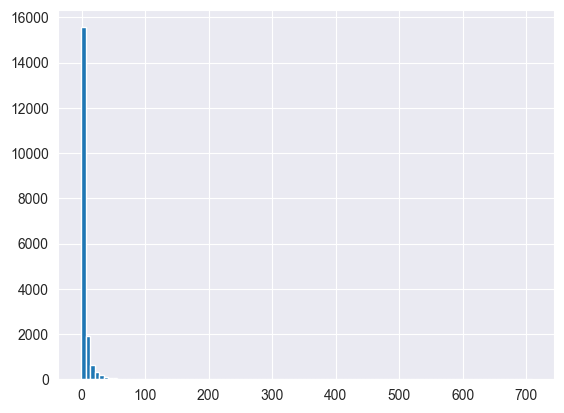

In [67]:
avg_sales['avg'].hist(bins=100)

In [68]:
monthly_sales_threshold = 8
high_sales_goods = avg_sales[avg_sales['avg']>monthly_sales_threshold]['GoodsID']
low_sales_goods = avg_sales[avg_sales['avg']<=monthly_sales_threshold]['GoodsID']
high_sales_goods

0        50608
1        50609
2        50610
14       50639
21       50651
         ...  
20001    74214
20010    74269
20013    74544
20014    74554
20015    74555
Name: GoodsID, Length: 2617, dtype: int64

In [69]:
monthly=pd.merge(high_sales_goods, monthly, on='GoodsID', how='inner')

# Train/Test Split

In [70]:
# Prepare training data
# Features: lag, rolling stats, price, year, month, quarter
feature_cols = all_features
X = monthly[feature_cols]
y = monthly['MainQty']

# Train/test split (chronological)
# last 2 months as test
split_date = monthly['date'].max() - pd.DateOffset(months=2)
train_idx = monthly['date'] <= split_date
test_idx = monthly['date'] > split_date

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [71]:
monthly

,GoodsID,year,month,quarter,MainQty,Price,year_month_order,date,lag_1,lag_2,...,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_3,rolling_6,rolling_9,rolling_12
0,50608,2024,12,4,15.0,1.964091e+06,24300,2024-12-01,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50608,2025,1,1,16.0,2.305500e+06,24301,2025-01-01,15.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50608,2025,2,1,8.0,1.933333e+06,24302,2025-02-01,16.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,11.333333,NaN,NaN,NaN
3,50608,2025,3,1,15.0,2.175000e+06,24303,2025-03-01,8.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN
4,50608,2025,4,2,8.0,1.657143e+06,24304,2025-04-01,15.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87961,74555,2025,8,3,NaN,NaN,24308,2025-08-01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87962,74555,2025,9,3,NaN,NaN,24309,2025-09-01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87963,74555,2025,10,4,NaN,NaN,24310,2025-10-01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87964,74555,2025,11,4,NaN,NaN,24311,2025-11-01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
print("=== بررسی X_train ===")
print(f"Shape: {X_train.shape}")
print(f"NaN count: {X_train.isna().sum().sum()}")
print(f"Inf count: {np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()}")

print("\n=== بررسی y_train ===")
print(f"Shape: {y_train.shape}")
print(f"NaN count: {y_train.isna().sum()}")
print(f"Inf count: {np.isinf(y_train).sum()}")
print(f"Min: {y_train.min()}")
print(f"Max: {y_train.max()}")

=== بررسی X_train ===
Shape: (82781, 32)
NaN count: 1077558
Inf count: 0

=== بررسی y_train ===
Shape: (82781,)
NaN count: 19249
Inf count: 0
Min: -285.0
Max: 3021.0


# Model training and Hyperparameter Tuning

In [60]:
tscv = TimeSeriesSplit(n_splits=3)

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


ValueError: 
All the 324 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "D:\Programming\pycharm_project\PythonProject\daneshgah\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\Programming\pycharm_project\PythonProject\daneshgah\.venv\Lib\site-packages\xgboost\core.py", line 730, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "D:\Programming\pycharm_project\PythonProject\daneshgah\.venv\Lib\site-packages\xgboost\sklearn.py", line 1055, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Programming\pychar

# Evaluation

In [19]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


MAE: 13.65
RMSE: 32.64
R²: 0.525


# Forcast Next Month

In [20]:

# Forecast for each GoodsID for the next month
latest_date = monthly['date'].max()
forecast_month = latest_date + pd.DateOffset(months=1)

latest_features = (
    monthly.sort_values(['GoodsID', 'date'])
    .groupby('GoodsID')
    .tail(1)[['GoodsID'] + feature_cols]
)

latest_features['forecast_month'] = forecast_month
latest_features['predicted_next_month'] = best_model.predict(latest_features[feature_cols])

latest_features[['GoodsID', 'forecast_month', 'predicted_next_month']]


,GoodsID,forecast_month,predicted_next_month
6,50718,2025-12-01,36.813152
15,50729,2025-12-01,36.135872
19,50907,2025-12-01,25.896025
33,50923,2025-12-01,26.513420
41,51063,2025-12-01,14.261518
...,...,...,...
37887,74005,2025-12-01,14.755756
37896,74011,2025-12-01,21.091179
37904,74044,2025-12-01,21.758434
37933,74150,2025-12-01,13.153926


In [21]:
def plot_historical_and_predictions(target_goodsid):

    # Prepare historical + prediction data
    product_df = monthly[monthly['GoodsID'] == target_goodsid].copy()
    product_df = product_df.sort_values('date')

    # Predict on all available months
    product_df['predicted'] = best_model.predict(product_df[feature_cols])

    # Prepare next-month forecast (if available)
    forecast_row = latest_features[latest_features['GoodsID'] == target_goodsid]

    # Plot
    plt.figure(figsize=(12,6))

    # Actual sales (ground truth)
    plt.plot(
        product_df['date'],
        product_df['MainQty'],
        label='Actual Sales',
        marker='o',
        color='steelblue',
    )

    # Model predictions (train + test)
    plt.plot(
        product_df['date'],
        product_df['predicted'],
        label='Model Prediction',
        linestyle='--',
        marker='.',
        color='orange',
    )

    # Add forecast for next month (if available)
    if not forecast_row.empty:
        plt.scatter(
            forecast_row['forecast_month'],
            forecast_row['predicted_next_month'],
            color='red',
            s=120,
            marker='*',
            label='Next Month Forecast'
        )

    # Visual split marker
    plt.axvline(split_date, color='gray', linestyle=':', label='Train/Test Split')

    # Labels and formatting
    plt.title(f"GoodsID {target_goodsid} — Historical, Predicted, and Forecasted Sales")
    plt.xlabel("Date")
    plt.ylabel("Sales Quantity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


GoodId = 55119


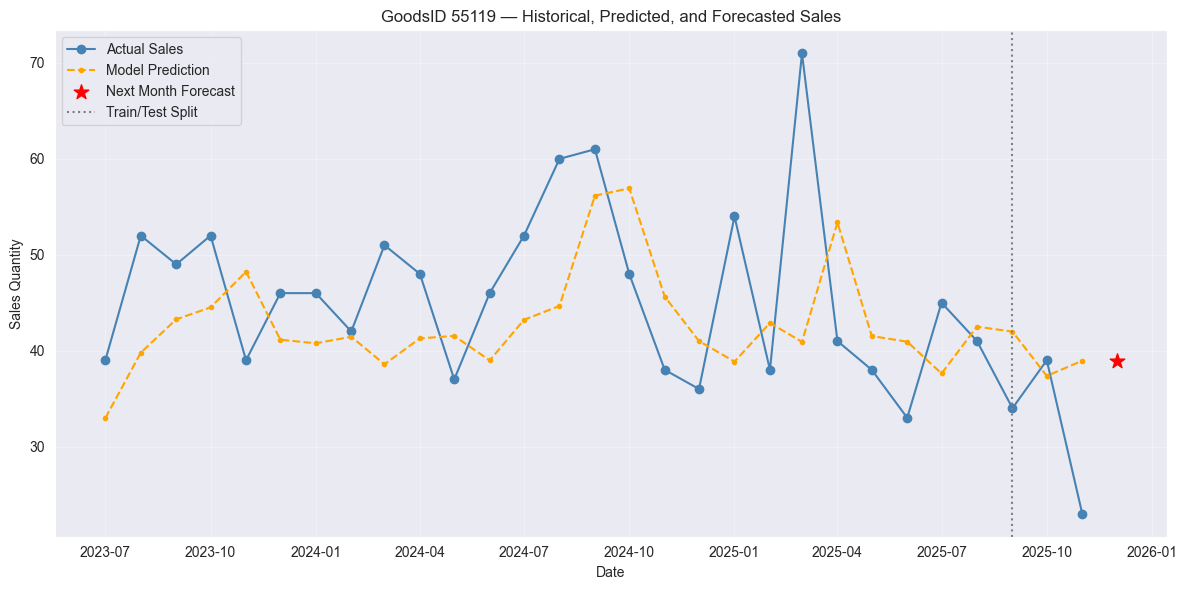

In [27]:
good_id = monthly[~monthly['lag_8'].isna()].sample(1).iloc[0,0]
print(f'GoodId = {good_id}')
plot_historical_and_predictions(good_id)
